

**The Hybrid Equation: KNOWN PHYSICS + UDE**
$$ C_m \frac{dV}{dt} = I_{ext} - \mathbf{NN(V)} - I_{K}(V) - I_{L}(V) $$


In [ ]:
using Pkg

Pkg.add([
    "Lux",
    "ComponentArrays",
    "SciMLSensitivity",
    "DifferentialEquations",
    "Optimization",
    "OptimizationOptimisers",
    "OptimizationOptimJL",
    "Statistics",
    "JLD2",
    "Plots",
    "Printf",
    "Zygote"
])

    Updating registry at `C:\Users\nirbh\.julia\registries\General.toml`
   Resolving package versions...
  Installing 1 artifacts
   Installed artifact Ghostscript           55.7 MiB
    Updating `C:\Users\nirbh\Neural_Spiking_Dynamics\Project.toml`
  [b0b7db55] + ComponentArrays v0.15.33
⌃ [b2108857] + Lux v1.29.0
  [10745b16] + Statistics v1.11.1
  [de0858da] + Printf v1.11.0
    Updating `C:\Users\nirbh\Neural_Spiking_Dynamics\Manifest.toml`
  [b0b7db55] + ComponentArrays v0.15.33
  [8d63f2c5] + DispatchDoctor v0.4.28
  [21656369] + ExpressionExplorer v1.1.4
⌃ [b2108857] + Lux v1.29.0
⌃ [bb33d45b] + LuxCore v1.5.0
⌃ [82251201] + LuxLib v1.15.0
  [a3311ec8] + ReactantCore v0.1.17
  [d49dbf32] + WeightInitializers v1.3.1
⌃ [c8ffd9c3] ~ MbedTLS_jll v2.28.6+0 ⇒ v2.28.6+0
  [f43a241f] ↑ Downloads v1.6.0 ⇒ v1.7.0
  [ac6e5ff7] + JuliaSyntaxHighlighting v1.12.0
  [37e2e46d] ↑ LinearAlgebra v1.11.0 ⇒ v1.12.0
  [ca575930] ↑ NetworkOptions v1.2.0 ⇒ v1.3.0
  [44cfe95a] ↑ Pkg v1.11.0 ⇒ v1.12.1


In [ ]:
using Lux, Random, ComponentArrays, SciMLSensitivity, DifferentialEquations
using Optimization, OptimizationOptimisers, OptimizationOptimJL
using Statistics, JLD2, Plots, Printf, Zygote

# Set seed for reproducibility
Random.seed!(1234)
println("✅ Packages Loaded & Seed Set.")

In [ ]:
data = load("Data/synthetic_data/noise_0_hh_2d_model.jld")

In [3]:
data = load("Data/synthetic_data/noise_0_hh_2d_model.jld")

# Extract and explicitly convert to Float64
t_train = Float64.(data["t"])
V_train = Float64.(data["V"])
n_train = Float64.(data["n"]) # We need this for the 2-input requirement!

println("📊 Data Loaded: $(length(t_train)) points.")


📊 Data Loaded: 501 points.


In [4]:
# 1. Physical Constants (Reduced HH Model) - Float64
const C_m  = 1.0
const g_K  = 36.0
const E_K  = -77.0
const g_L  = 0.3
const E_L  = -54.387
const g_Na = 120.0 
const E_Na = 50.0

50.0

In [25]:
# 2. Known Kinetics for Potassium (n)
α_n(V)   = 0.01 * (V + 55.0) / (1.0 - exp(-(V + 55.0) / 10.0))
β_n(V)   = 0.125 * exp(-(V + 65.0) / 80.0)
n_inf(V) = α_n(V) / (α_n(V) + β_n(V))
tau_n(V) = 1.0 / (α_n(V) + β_n(V))

# 3. Stimulus Function (Matches your synthetic generation)
function Stimulus(t)
    # A pulse between 10ms-11ms and 30ms-31ms
    if (t >= 10.0 && t < 11.0) || (t >= 30.0 && t < 31.0)
        return 20.0
    else
        return 0.0
    end
end

Stimulus (generic function with 1 method)

In [26]:
# 4. Normalization (Only for V)
# const V_mean = mean(V_train)
# const V_std  = std(V_train)
# norm_input(v) = (v - V_mean) / V_std

println("✅ Physics & Normalization Defined.")

✅ Physics & Normalization Defined.


In [27]:
println("Mean: ", V_mean)
println("Std: ", V_std)

Mean: -64.08357298526319
Std: 9.39623570385486


In [28]:
# Architecture: 2 Inputs (V, n) -> 1 Output (Sodium Current)
# Using Tanh for smoothness
NN_Model = Chain(
    # CHANGE 1 => 64. Input layer takes 2 values: [V, n]
    Dense(2, 64, tanh), 
    Dense(64, 32, tanh),
    Dense(32, 1)
) |> f64

# Initialize parameters in Float64
rng = Random.default_rng()
p_init, st = Lux.setup(rng, NN_Model)
p_nn = ComponentArray(p_init) .|> Float64 # Force Float64

println("🧠 Neural Network Initialized.")
println("   Structure: [V, n] -> [64] -> [32] -> [I_Na]")

🧠 Neural Network Initialized.
   Structure: [V, n] -> [64] -> [32] -> [I_Na]


In [29]:
function hodgkin_huxley_UDE!(du, u, p, t)
    V, n = u
    
    # Feed raw V and n directly into the network (no normalization)
    pred_I_Na = NN_Model([V, n], p, st)[1][1]
    
    # Physics (Potassium & Leak are known)
    I_K = g_K * (n^4) * (V - E_K)
    I_L = g_L * (V - E_L)
    I_ext = Stimulus(t)

    # Dynamics
    du[1] = (I_ext - pred_I_Na - I_K - I_L) / C_m
    du[2] = (n_inf(V) - n) / tau_n(V)
end

# Define Problem
u0_true = [V_train[1], n_train[1]]
tspan = (0.0, 50.0) # Matches your data duration
prob_nn = ODEProblem(hodgkin_huxley_UDE!, u0_true, tspan, p_nn)

println("✅ UDE System & Problem Defined.")

# Define Problem
u0_true = [V_train[1], n_train[1]]
tspan = (0.0, 50.0) # Matches your data duration
prob_nn = ODEProblem(hodgkin_huxley_UDE!, u0_true, tspan, p_nn)

println("✅ UDE System & Problem Defined.")

✅ UDE System & Problem Defined.
✅ UDE System & Problem Defined.


In [30]:
function predict_ude(p)
    _prob = remake(prob_nn, p=p)
    
    solve(_prob, Tsit5(), saveat=t_train,
          reltol=1e-4, abstol=1e-4,
          sensealg=InterpolatingAdjoint(autojacvec=ZygoteVJP()))
end

function loss(p)
    pred = predict_ude(p)
    
    # Crash Handling: If solver fails, return infinity
    if pred.retcode != :Success
        return 1e6
    end
    
    # MSE on Voltage Only
    # pred[1,:] is V, pred[2,:] is n (we hide n from loss generally)
    loss_val = sum(abs2, pred[1, :] .- V_train)
    return loss_val
end

println("✅ Loss Function Defined.")


✅ Loss Function Defined.


In [31]:
# Callback Setup
losses = Float64[]
min_loss = Inf
const SAVE_PATH = "ude_best_model_copy.jld2"

function callback(state, l)
    push!(losses, l)
    
    # Save if best
    if l < min_loss
        global min_loss = l
        # Save best model + full loss history
        jldsave(SAVE_PATH; 
            params=state.u, 
            loss=l, 
            losses=losses)  # ← Added loss history
    end
    if(length(losses) % 1 == 0)
        println("Iter: $(length(losses)) | Loss: $l")
    end
    
    return false
end

callback (generic function with 1 method)

In [32]:
optf = Optimization.OptimizationFunction(
    (x, p) -> loss(x),          # the loss callable
    Optimization.AutoZygote()   # automatic differentiation backend
)

OptimizationFunction{true, AutoZygote, var"#5#6", Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, typeof(SciMLBase.DEFAULT_OBSERVED_NO_TIME), Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing}(var"#5#6"(), AutoZygote(), nothing, nothing, nothing, nothing, nothing, nothing, nothing, nothing, nothing, nothing, nothing, nothing, nothing, SciMLBase.DEFAULT_OBSERVED_NO_TIME, nothing, nothing, nothing, nothing, nothing, nothing, nothing, nothing, nothing, nothing)

In [ ]:
# Phase 1: Fast exploration (200 iters at 0.01)
optprob = Optimization.OptimizationProblem(optf, p_nn)
res1 = Optimization.solve(
    optprob, 
    OptimizationOptimisers.Adam(0.001),  # Full module path!
    callback=callback, 
    maxiters=100
)

# # Phase 2: Fine-tuning (500 iters at 0.001)
# optprob2 = Optimization.OptimizationProblem(optf, res1.u)  # Start from Phase 1 result
# res2 = Optimization.solve(
#     optprob2, 
#     OptimizationOptimisers.Adam(0.01),  # Smaller LR for stability
#     callback=callback, 
#     maxiters=1000
# )

Iter: 1 | Loss: 35681.607792600946
Iter: 2 | Loss: 26143.95337109296
Iter: 3 | Loss: 26173.216080769987
Iter: 4 | Loss: 35628.790817165696
Iter: 5 | Loss: 35388.85883575612
Iter: 6 | Loss: 25858.89196552928
Iter: 7 | Loss: 35331.36704195964
Iter: 8 | Loss: 26475.0623783377
Iter: 9 | Loss: 35200.897987013544
Iter: 10 | Loss: 35573.7183413598
Iter: 11 | Loss: 44971.316948847736
Iter: 12 | Loss: 26207.4377708807
Iter: 13 | Loss: 26364.614439827277


In [ ]:
using JLD2,ComponentArrays
data2 = load("ude_best_model_copy.jld2")          

Dict{String, Any} with 3 entries:
  "losses" => [35625.4, 25559.3, 35724.5, 24803.3, 24149.2, 24501.3, 23779.7, 3…
  "params" => (layer_1 = (weight = [-1.41462 0.952373; 0.279777 -0.639264; … ; …
  "loss"   => 18762.2

In [ ]:
losses = data2["losses"]

73-element Vector{Float64}:
 35625.415828576886
 25559.26792189412
 35724.52207663374
 24803.29885706523
 24149.165463641522
 24501.333102173485
 23779.716972867896
 34904.01128849286
 23735.3883270593
 22955.502961249465
 24216.974674758276
 23111.770703029742
 35333.51623790628
     ⋮
 19505.384580524904
 20347.573393388786
 20470.237794567976
 33042.70968328511
 29736.30984694356
 33079.194103076225
 33222.55788849398
 19236.89732453274
 19221.835014165466
 19493.97398372271
 32906.67752322329
 18762.240944395602

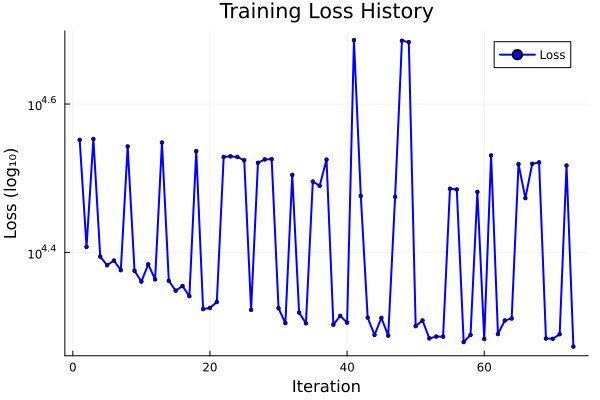

In [ ]:
losses = data2["losses"]
plot(losses, 
    yscale=:log10,
    xlabel="Iteration",
    ylabel="Loss (log₁₀)",
    title="Training Loss History",
    label="Loss",
    linewidth=2,
    color=:blue,
    marker=:circle,
    markersize=2
)